# 01 · EDA dirigido al modelado — Recepción de juegos en Steam
**Proyecto ML (Project Break II) · Autor: Isaac Frías**

**Pregunta de negocio:** ¿podemos predecir si un juego de Steam será *bien recibido* por la comunidad
a partir de sus características (precio, género, plataformas, idiomas, etc.)?

Este EDA prepara el modelado: define la variable objetivo, detecta fugas de información
(*data leakage*), estudia la relación de cada feature con el target y decide qué variables y
transformaciones entran al modelo.

## 0 · Setup

In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.utils.data_loader import (
    load_raw, clean_steam, add_features, add_target,
    resumen_calidad, COLS_LEAKAGE, MIN_REVIEWS_TARGET, UMBRAL_POSITIVA,
)
sns.set_theme(style="whitegrid")
IMG = ROOT / "src" / "img"; IMG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 60)
print("OK · umbral positiva:", UMBRAL_POSITIVA, "% | reseñas minimas:", MIN_REVIEWS_TARGET)

OK · umbral positiva: 70 % | reseñas minimas: 50


## 1 · Carga y preparación
`load_raw` repara el desalineamiento de columnas del CSV original (junta `Discount` y `DLC count`).
Cargamos, limpiamos y creamos features en tres pasos.

In [2]:
CSV = os.environ.get("STEAM_CSV")
df_raw = load_raw(CSV) if CSV else load_raw()
print(f"Bruto: {df_raw.shape[0]:,} juegos x {df_raw.shape[1]} columnas")
df = add_features(clean_steam(df_raw))
print(f"Tras limpieza + features: {df.shape[0]:,} x {df.shape[1]}")

Bruto: 122,611 juegos x 40 columnas


Tras limpieza + features: 58,251 x 42


## 2 · Definición de la variable objetivo
- Solo juegos con **≥ 50 reseñas** (para que el % de positivas sea fiable).
- `recepcion_positiva = 1` si **% de reseñas positivas ≥ 70 %**, si no 0. Clasificación binaria.

In [3]:
dft = add_target(df)
print(f"Poblacion de modelado (>= {MIN_REVIEWS_TARGET} reseñas): {dft.shape[0]:,} juegos")
balance = dft["recepcion_positiva"].value_counts().sort_index()
pct_pos = balance.get(1, 0) / len(dft) * 100
print(f"Clase 0 (mala/mixta): {balance.get(0,0):,}")
print(f"Clase 1 (positiva)  : {balance.get(1,0):,}")
print(f"% clase positiva    : {pct_pos:.1f}%")

Poblacion de modelado (>= 50 reseñas): 30,620 juegos
Clase 0 (mala/mixta): 7,601
Clase 1 (positiva)  : 23,019
% clase positiva    : 75.2%


### 2.1 · Distribución del target y balance
**Hallazgo clave:** clases **desbalanceadas (~75/25)** → usaremos F1 / ROC-AUC y `class_weight`.

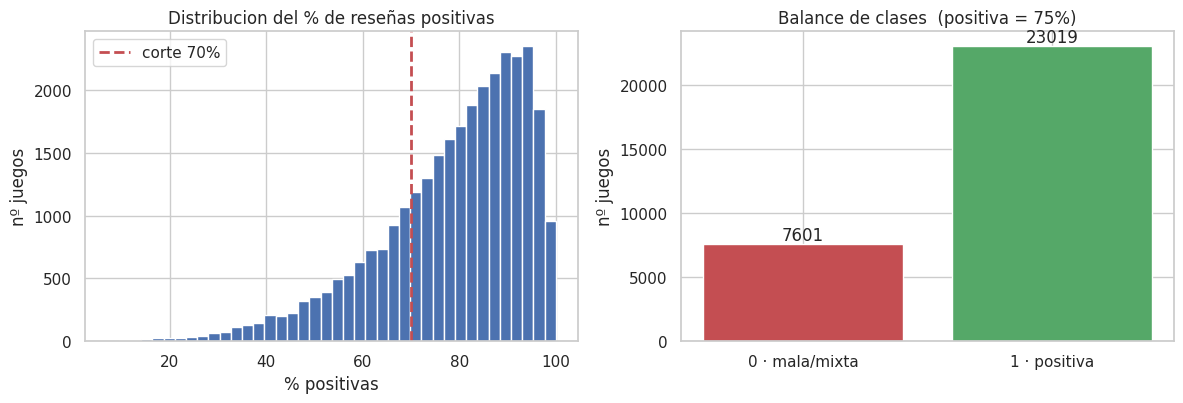

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(dft["pct_positivas"], bins=40, color="#4C72B0", edgecolor="white")
ax[0].axvline(UMBRAL_POSITIVA, color="#C44E52", ls="--", lw=2, label=f"corte {UMBRAL_POSITIVA}%")
ax[0].set_title("Distribucion del % de reseñas positivas"); ax[0].set_xlabel("% positivas"); ax[0].set_ylabel("nº juegos"); ax[0].legend()
barras = ax[1].bar(["0 · mala/mixta", "1 · positiva"], balance.values, color=["#C44E52", "#55A868"], edgecolor="white")
ax[1].bar_label(barras, fmt="%d"); ax[1].set_title(f"Balance de clases  (positiva = {pct_pos:.0f}%)"); ax[1].set_ylabel("nº juegos")
plt.tight_layout(); plt.savefig(IMG / "01_target_balance.png", dpi=110, bbox_inches="tight"); plt.show()

## 3 · Calidad de datos

In [5]:
resumen_calidad(dft).sort_values("pct_nulos", ascending=False).head(15)

,dtype,nulos,pct_nulos,unicos,ejemplo
Publishers,object,227,0.74,14595,MangaGamer
Categories,object,164,0.54,6214,"Single-player,Steam Trading Cards,Steam Cloud,..."
Genres,object,83,0.27,1554,Adventure
Estimated owners,object,0,0.00,13,0 - 20000
Peak CCU,int64,0,0.00,1100,0
Required age,int64,0,0.00,11,0
Price,float64,0,0.00,619,5.24
Discount,int64,0,0.00,86,65
AppID,int64,0,0.00,30620,496350
Name,object,0,0.00,30506,Supipara - Chapter 1 Spring Has Come!


**Observaciones:** `Metacritic score` casi siempre vacío (poco usable); `Release date` con algún
nulo (toleramos NaN en `anyo_lanzamiento`); el resto de features candidatas están completas.

## 4 · ⚠️ Fuga de información (data leakage)
El target se calcula a partir de `Positive`/`Negative`. Por tanto **NO** se pueden usar como
predictores las variables derivadas de las mismas reseñas: `Positive`, `Negative`, `total_reviews`,
`pct_positivas`, `User score`, `Recommendations`. Se excluyen (`COLS_LEAKAGE`).

In [6]:
print("Columnas excluidas por leakage:")
for c in COLS_LEAKAGE: print("  -", c)

Columnas excluidas por leakage:
  - Positive
  - Negative
  - total_reviews
  - pct_positivas
  - User score
  - Recommendations
  - recepcion_positiva


## 5 · Relación feature → target

### 5.1 · Modelo de negocio (F2P vs Pago)
**Hallazgo:** los de **pago** se reciben mejor que los **F2P**.

                 mean   size
modelo_negocio              
F2P             0.687   4061
Pago            0.762  26559


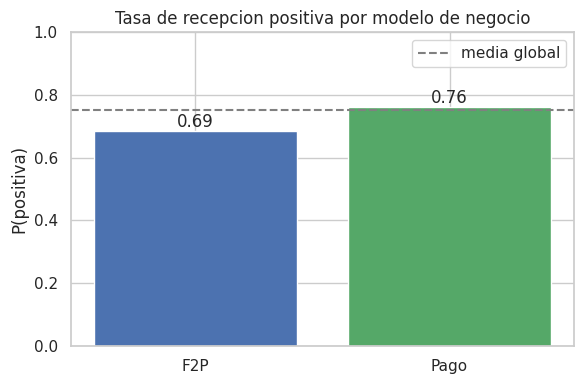

In [7]:
tasa = dft.groupby("modelo_negocio")["recepcion_positiva"].agg(["mean", "size"])
print(tasa.round(3).to_string())
fig, ax = plt.subplots(figsize=(6, 4))
b = ax.bar(tasa.index, tasa["mean"], color=["#4C72B0", "#55A868"], edgecolor="white")
ax.bar_label(b, fmt="%.2f"); ax.set_ylim(0, 1)
ax.axhline(dft["recepcion_positiva"].mean(), color="grey", ls="--", label="media global")
ax.set_title("Tasa de recepcion positiva por modelo de negocio"); ax.set_ylabel("P(positiva)"); ax.legend()
plt.tight_layout(); plt.savefig(IMG / "02_f2p_vs_target.png", dpi=110, bbox_inches="tight"); plt.show()

### 5.2 · Género principal
**Hallazgo:** diferencias claras por género → categórica con señal, se codificará.

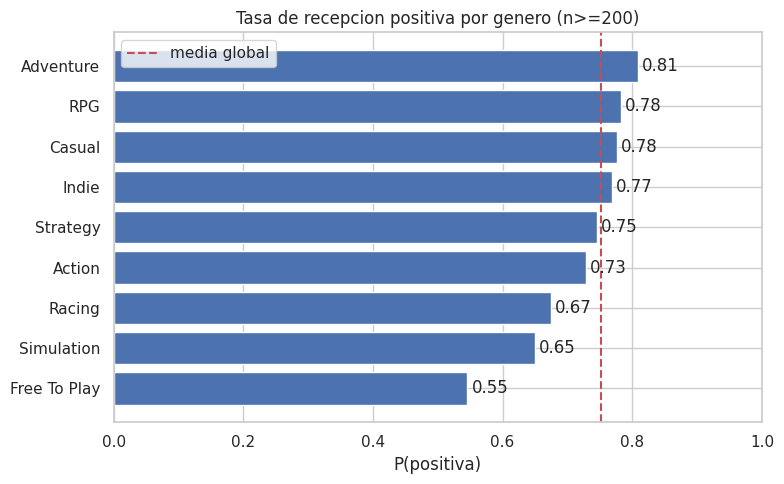

In [8]:
g = (dft.groupby("genero_principal")["recepcion_positiva"].agg(["mean","size"]).query("size >= 200").sort_values("mean"))
fig, ax = plt.subplots(figsize=(8, 5))
b = ax.barh(g.index, g["mean"], color="#4C72B0", edgecolor="white"); ax.bar_label(b, fmt="%.2f", padding=3)
ax.axvline(dft["recepcion_positiva"].mean(), color="#C44E52", ls="--", label="media global")
ax.set_xlim(0, 1); ax.set_title("Tasa de recepcion positiva por genero (n>=200)"); ax.set_xlabel("P(positiva)"); ax.legend()
plt.tight_layout(); plt.savefig(IMG / "03_genero_vs_target.png", dpi=110, bbox_inches="tight"); plt.show()

### 5.3 · Features numéricas vs target
Escala log donde hay colas largas. **Hallazgo:** los bien recibidos tienen más playtime y algo más de precio.

/sessions/wizardly-intelligent-einstein/tmp/ipykernel_10/1058655268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="recepcion_positiva", y=col, ax=a, palette=["#C44E52", "#55A868"], showfliers=False)
/sessions/wizardly-intelligent-einstein/tmp/ipykernel_10/1058655268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="recepcion_positiva", y=col, ax=a, palette=["#C44E52", "#55A868"], showfliers=False)
/sessions/wizardly-intelligent-einstein/tmp/ipykernel_10/1058655268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxpl

/sessions/wizardly-intelligent-einstein/tmp/ipykernel_10/1058655268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="recepcion_positiva", y=col, ax=a, palette=["#C44E52", "#55A868"], showfliers=False)


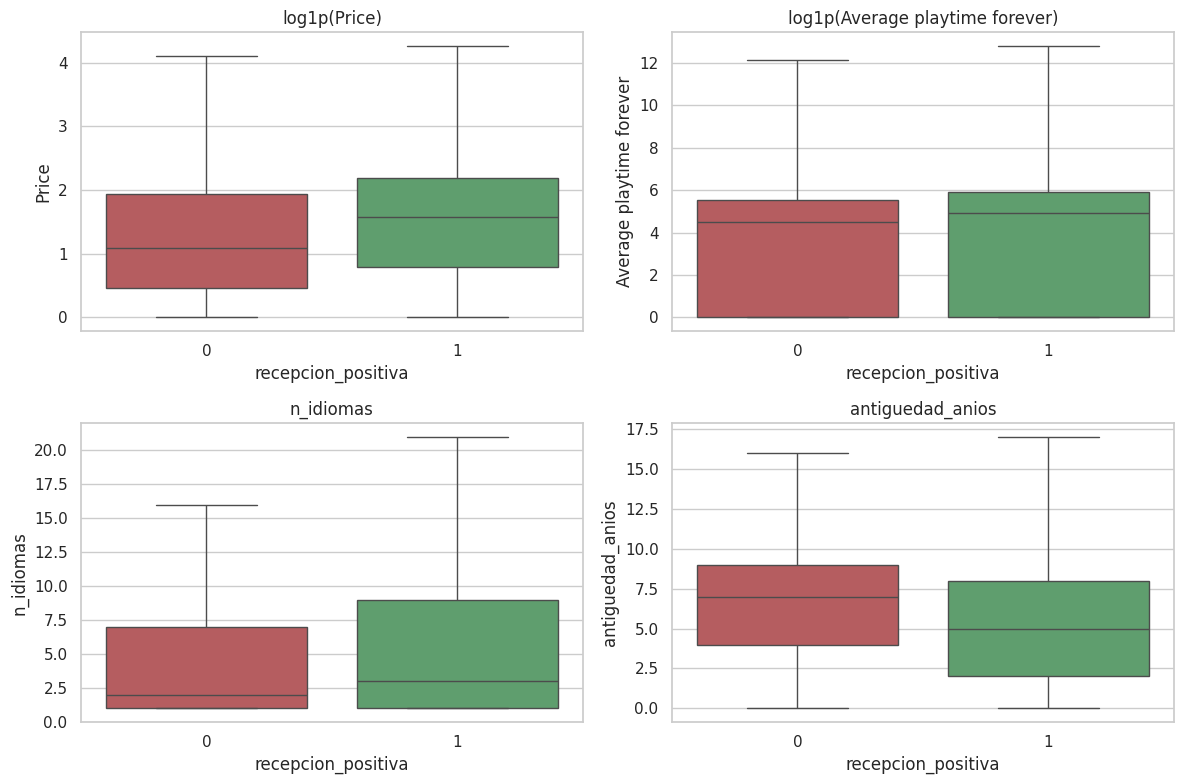

In [9]:
num = ["Price", "Average playtime forever", "n_idiomas", "antiguedad_anios"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for a, col in zip(axes.ravel(), num):
    d = dft[[col, "recepcion_positiva"]].copy()
    if col in ("Price", "Average playtime forever"):
        d[col] = np.log1p(d[col]); etq = f"log1p({col})"
    else:
        etq = col
    sns.boxplot(data=d, x="recepcion_positiva", y=col, ax=a, palette=["#C44E52", "#55A868"], showfliers=False)
    a.set_title(etq); a.set_xlabel("recepcion_positiva")
plt.tight_layout(); plt.savefig(IMG / "04_numericas_vs_target.png", dpi=110, bbox_inches="tight"); plt.show()

### 5.4 · Correlación entre features numéricas candidatas (sin leakage)

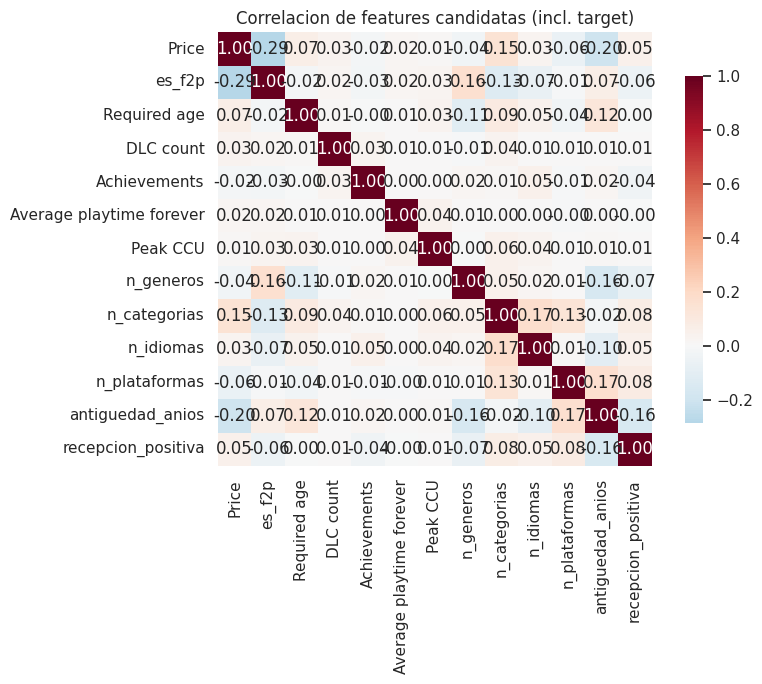

In [10]:
feat_num = ["Price", "es_f2p", "Required age", "DLC count", "Achievements",
            "Average playtime forever", "Peak CCU", "n_generos", "n_categorias",
            "n_idiomas", "n_plataformas", "antiguedad_anios", "recepcion_positiva"]
corr = dft[feat_num].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlacion de features candidatas (incl. target)")
plt.tight_layout(); plt.savefig(IMG / "05_correlacion.png", dpi=110, bbox_inches="tight"); plt.show()

## 6 · Conclusiones para el modelado
**Target:** clasificación binaria `recepcion_positiva` (≥70 % positivas) sobre juegos con ≥50 reseñas;
clases ~75/25 → métricas F1 y ROC-AUC.
**Features (sin leakage):** `es_f2p`, `Price`, `Required age`, `DLC count`, `Achievements`,
`Average playtime forever`, `Peak CCU`, `n_generos`, `n_categorias`, `n_idiomas`, `n_plataformas`,
`antiguedad_anios`, `genero_principal`, `tiene_publisher`.
**Transformaciones:** `log1p` en colas largas; One-Hot de `genero_principal`; imputación y escalado.
**Excluidas por fuga:** `Positive`, `Negative`, `total_reviews`, `pct_positivas`, `User score`, `Recommendations`.
**Siguiente:** `02_preprocessing.ipynb` (split + ColumnTransformer) y `main.ipynb` (modelado).